ML – MIDTERM EXAM (100 Marks)

This notebook is your **single submission file** for the Midterm.

- **Total marks:** 100  
  - Section A: 40 marks  
  - Section B: 60 marks  
- Answer **all questions** in this notebook.  
- Do **not** create a separate PDF.  
- Use clear headings, code, and explanations.

- Run all cells before submitting so all outputs are visible.
- Set the Colab file's shareable link to ‘Anyone with the link’ and ‘View’ access, then submit it in the Phitron Assignment module's Assignment submission section.

In [65]:
# Common imports for Section B (run once)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

plt.rcParams['figure.figsize'] = (6, 4)
plt.rcParams['axes.grid'] = True

---

## SECTION A – Short Application Questions (40 Marks)

Write your answers in the provided **answer cells** in this notebook. Use text, formulas, and short reasoning.

Marks for each question are clearly mentioned.

---

### Q1. Descriptive Statistics and Distributions (15 marks)

A dataset of monthly customer spending (in dollars) is:

`[30, 35, 32, 34, 33, 500, 31, 34, 32, 33]`

1. Compute the **median** and **IQR**. Show your working clearly.  
2. Use the **IQR rule** to check if 500 is an outlier. Show your steps and the fences.  
3. Explain in 3 to 5 sentences why **median + IQR** may be better than **mean + standard deviation** for this dataset.

Write your full answer in the cell below.


#### Q1 Answer (Student)

**Median:**

Sorted data = [30, 31, 32, 32, 33, 33, 34, 34, 35, 500]

Median = (33 + 33) / 2 = 33

**IQR:**

Q1 = 32, Q3 = 34

IQR = Q3 - Q1 = 34 - 32 = 2

Outlier Check (IQR Rule):

Lower Fence = 32 - 1.5 × 2 = 29

Upper Fence = 34 + 1.5 × 2 = 37

Since 500 > 37, 500 is an outlier.

**Explanation:**
For this dataset, the value 500 is extremely larger than the other observations. Such an extreme value can significantly increase the mean and standard deviation, making them less representative of the typical customer spending. The median and IQR are more robust because they are not heavily affected by outliers. Therefore, median and IQR provide a better summary of the center and spread of this dataset.

In [66]:
# Optional helper code for Q1 (not required)
data_q1 = [30, 35, 32, 34, 33, 500, 31, 34, 32, 33]
data_q1

[30, 35, 32, 34, 33, 500, 31, 34, 32, 33]

### Q2. Bayes and Probability in ML (10 marks)

A disease affects **1 percent** of people.  
A test has:  
- Sensitivity: **90 percent**  
- Specificity: **92 percent**  

A random person tests positive.

1. Compute the **positive predictive value (PPV)** using Bayes theorem. Show all steps with probabilities.  
2. If prevalence rises to **20 percent**, explain in 3 to 4 sentences whether PPV increases or decreases and why. You may refer to the Bayes formula in words.

Write your full answer in the cell below.


#### Q2 Answer (Student)

P(Disease) = 0.01

P(No Disease) = 0.99

P(Positive | Disease) = 0.90

P(Positive | No Disease) = 1 - 0.92 = 0.08

Using Bayes Theorem:

P(Disease | Positive)

= (0.90 × 0.01) / [(0.90 × 0.01) + (0.08 × 0.99)]

= 0.009 / (0.009 + 0.0792)

= 0.009 / 0.0882

= 0.102 ≈ 10.2%

So, the Positive Predictive Value (PPV) is 10.2%.

**Explanation:**

If the prevalence increases to 20%, the PPV will also increase. This is because more people in the population actually have the disease. As a result, a positive test result is more likely to be a true positive. Therefore, higher prevalence leads to a higher PPV.

### Q3. ML Pipeline Thinking (15 marks)

Columns in a new dataset:

- `age` (numeric)  
- `region` (categorical with 7 levels)  
- `daily_clicks` (numeric)  
- `premium_user` (0 or 1 target)

1. Identify the **type of ML task**. (1 or 2 lines)  
2. List **four preprocessing steps** that would be reasonable for this dataset. (bullet points are fine)  
3. In one short paragraph (6 to 8 sentences), describe the **end to end ML pipeline** you would follow for this problem, from raw data to model evaluation.

Write your full answer in the cell below.


#### Q3 Answer (Student)
**1. Type of ML Task:**

This is a supervised learning classification problem because the target variable `premium_user` is binary (0 or 1).

**2. Preprocessing Steps:**
- Handle missing values (if any) using mean/median for numeric columns and mode for categorical column
- Convert `region` into numeric form using one-hot encoding
- Scale numeric features like `age` and `daily_clicks` using StandardScaler or RobustScaler
- Split the dataset into training and testing sets

**3. End-to-End ML Pipeline:**

First we collect and load the raw dataset into a pandas DataFrame. Then we check for missing values and clean the data by handling them properly. After that, we perform feature engineering by encoding the categorical column region and scaling the numeric features like age and daily_clicks. Next, we split the dataset into training and testing sets to evaluate model performance fairly. Then we train a classification model such as Logistic Regression or Decision Tree using the training data. After training, we make predictions on the test set. Finally, we evaluate the model using metrics like accuracy, precision, recall, and F1-score to understand how well the model performs.


---

## SECTION B – Applied Coding Problems (60 Marks)

Answer **all three questions** in this section.

- Write clean, commented code.  
- After each main step, add a short markdown explanation of what you did and what you observe.  
- Make sure all plots are visible in the notebook.

Marks for each question are clearly mentioned.

---

### Q4. Applied EDA and Preprocessing (20 marks)

We work with the following dataset:

```python
import pandas as pd

df = pd.DataFrame({
    "age": [25, 30, None, 22, 45, 52, None],
    "region": ["north","south","north","east","west","west","south"],
    "purchases": [3, 10, 5, None, 20, 18, 9],
    "premium_user": [0,1,0,0,1,1,0]
})
```

**Tasks (20 marks total):**

1. **Compact EDA using pandas** (6 marks)  
   - Show missing value summary for each column.  
   - Show number of unique values per column.  
   - Show correlation among numeric columns.  
   - Plot:  
     - A histogram of `purchases`.  
     - A bar chart for `region` frequency.

2. **Preprocess the dataset using sklearn plus pandas** (9 marks)  
   - Impute `age` with **median**.  
   - Impute `purchases` with **mean**.  
   - One hot encode `region`.  
   - Scale all numeric columns using **RobustScaler**.

3. **Create one domain driven feature** (3 marks)  
   - Example ideas: `high_spender` based on `purchases`, or `age_group` bins, or an interaction like `age * purchases`.

4. Show the **final transformed dataframe** ready for model training. (2 marks)

Use short explanations in markdown to describe each main block of code.


In [67]:
# Q4 – Student Answer

# Step 1: Create the dataframe
df = pd.DataFrame({
    "age": [25, 30, None, 22, 45, 52, None],
    "region": ["north","south","north","east","west","west","south"],
    "purchases": [3, 10, 5, None, 20, 18, 9],
    "premium_user": [0,1,0,0,1,1,0]
})

df
# This creates the dataset and displays initial data.


,age,region,purchases,premium_user
0,25.0,north,3.0,0
1,30.0,south,10.0,1
2,NaN,north,5.0,0
3,22.0,east,NaN,0
4,45.0,west,20.0,1
5,52.0,west,18.0,1
6,NaN,south,9.0,0


In [68]:
# Step 2: Missing Values

df.isnull().sum()

# This shows missing values in each column.

,0
age,2
region,0
purchases,1
premium_user,0


In [69]:
# Step 3: Unique Values

df.nunique()

# This shows unique values per column.

,0
age,5
region,4
purchases,6
premium_user,2


In [70]:
# Step 4: Correlation
df.corr(numeric_only=True)

# Shows relationship between numeric features.

,age,purchases,premium_user
age,1.000000,0.923677,0.789534
purchases,0.923677,1.000000,0.825860
premium_user,0.789534,0.825860,1.000000


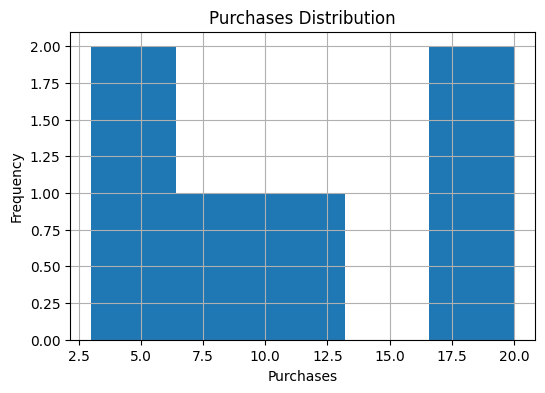

In [71]:
# Step 5: Hist (Purchases)
plt.hist(df["purchases"].dropna(), bins=5)
plt.title("Purchases Distribution")
plt.xlabel("Purchases")
plt.ylabel("Frequency")
plt.show()

# Shows distribution of purchases using histogram.

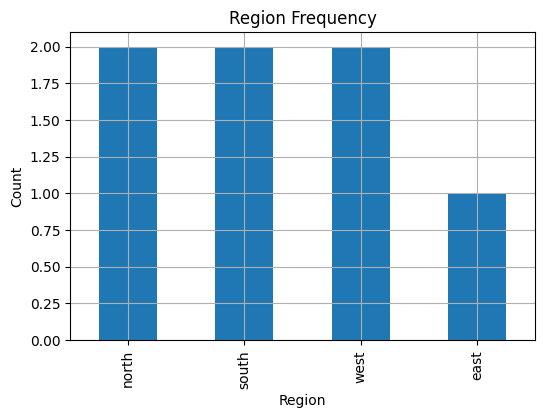

In [72]:
# Step 6: Bar Chart (Region)
df["region"].value_counts().plot.bar()
plt.title("Region Frequency")
plt.xlabel("Region")
plt.ylabel("Count")
plt.show()

# Shows how many users are from each region.

In [73]:
# Step 7: Impute Missing values
# age - median
age_imputer = SimpleImputer(strategy="median")
df["age"] = age_imputer.fit_transform(df[["age"]])

# purchases - mean
purchase_imputer = SimpleImputer(strategy="mean")
df["purchases"] = purchase_imputer.fit_transform(df[["purchases"]])

# Missing values are filled using median for age and mean for purchases.

In [74]:
# Step 8: One Hot Encoding region
df = pd.get_dummies(df, columns = ["region"])
df

# Converts categorical region column into numeric columns.

,age,purchases,premium_user,region_east,region_north,region_south,region_west
0,25.0,3.000000,0,False,True,False,False
1,30.0,10.000000,1,False,False,True,False
2,30.0,5.000000,0,False,True,False,False
3,22.0,10.833333,0,True,False,False,False
4,45.0,20.000000,1,False,False,False,True
5,52.0,18.000000,1,False,False,False,True
6,30.0,9.000000,0,False,False,True,False


In [75]:
# Step 9: Scaling (RobustScaler)
scaler = RobustScaler()
df[["age", "purchases"]] = scaler.fit_transform(df[["age", "purchases"]])
df

# Scales numeric values to reduce effect of outliers.

,age,purchases,premium_user,region_east,region_north,region_south,region_west
0,-0.5,-0.943820,0,False,True,False,False
1,0.0,0.000000,1,False,False,True,False
2,0.0,-0.674157,0,False,True,False,False
3,-0.8,0.112360,0,True,False,False,False
4,1.5,1.348315,1,False,False,False,True
5,2.2,1.078652,1,False,False,False,True
6,0.0,-0.134831,0,False,False,True,False


In [76]:
# Step 10: New Feature
df["high_spender"] = (df["purchases"] > 0.5).astype(int)
df

# Creates a new feature to identify high spending users.

,age,purchases,premium_user,region_east,region_north,region_south,region_west,high_spender
0,-0.5,-0.943820,0,False,True,False,False,0
1,0.0,0.000000,1,False,False,True,False,0
2,0.0,-0.674157,0,False,True,False,False,0
3,-0.8,0.112360,0,True,False,False,False,0
4,1.5,1.348315,1,False,False,False,True,1
5,2.2,1.078652,1,False,False,False,True,1
6,0.0,-0.134831,0,False,False,True,False,0


In [77]:
df

# Final dataset is clean, encoded, scaled and ready for ML model training.

,age,purchases,premium_user,region_east,region_north,region_south,region_west,high_spender
0,-0.5,-0.943820,0,False,True,False,False,0
1,0.0,0.000000,1,False,False,True,False,0
2,0.0,-0.674157,0,False,True,False,False,0
3,-0.8,0.112360,0,True,False,False,False,0
4,1.5,1.348315,1,False,False,False,True,1
5,2.2,1.078652,1,False,False,False,True,1
6,0.0,-0.134831,0,False,False,True,False,0


_Use additional code cells below for EDA, preprocessing, feature engineering, and final dataframe. Add brief explanations in markdown between code blocks._

---

### Q5. Applied Regression and Residual Analysis (20 marks)

We use this dataset:

```python
import pandas as pd

df2 = pd.DataFrame({
    "area_sqft": [800, 1000, 1200, 1500, 1800, 2000],
    "bedrooms": [2,2,3,3,4,4],
    "price": [120, 150, 170, 210, 260, 300]
})
```

**Tasks (20 marks total):**

1. Create the dataframe `df2`. (1 mark)  
2. Split the data into **train and test** with 80 percent train and 20 percent test. (3 marks)  
3. Fit a **LinearRegression** model to predict `price` from `area_sqft` and `bedrooms`. (4 marks)  
4. Print model **intercept**, **coefficients**, and **predictions** on the test set. (4 marks)  
5. Compute the following metrics on the test set. (6 marks)  
   - Mean Absolute Error (MAE)  
   - Root Mean Squared Error (RMSE)  
   - R squared (R²)  
6. Plot a **residual plot** with `y_true − y_pred` on the vertical axis and `y_pred` on the horizontal axis. (2 marks)  
   - Add a short note explaining what you observe from the residuals.

Again, use short markdown explanations to describe each step.


In [78]:
# Q5 – Student Answer

# Step 1: Create the dataframe
df2 = pd.DataFrame({
    "area_sqft": [800, 1000, 1200, 1500, 1800, 2000],
    "bedrooms": [2,2,3,3,4,4],
    "price": [120, 150, 170, 210, 260, 300]
})

df2

# This creates the dataset containing house area, bedrooms, and price.

,area_sqft,bedrooms,price
0,800,2,120
1,1000,2,150
2,1200,3,170
3,1500,3,210
4,1800,4,260
5,2000,4,300


In [92]:
# Step 2: Train-Test Split
X = df2[["area_sqft", "bedrooms"]]
y = df2["price"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Data is split into training (80%) and testing (20%) sets.

In [93]:
# Step 3: Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Linear Regression model is trained using training data.

LinearRegression()

In [81]:
# Step 4: Intercept, Coefficients, Predictions
# Intercept
print("Intercept:",model.intercept_)

# Coefficients
print("Coefficients:", model.coef_)

# Predictions
y_pred = model.predict(X_test)
print("Predictions:", y_pred)

# Shows model parameters and predictions on test data.

Intercept: -33.84615384615387
Coefficients: [0.15384615 5.38461538]
Predictions: [100.         130.76923077]


In [82]:
# Step 5: Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

# Model performance is evaluated using MAE, RMSE, and R² score.

MAE: 19.615384615384613
RMSE: 19.61915499208746
R2 Score: -0.7107166337935567


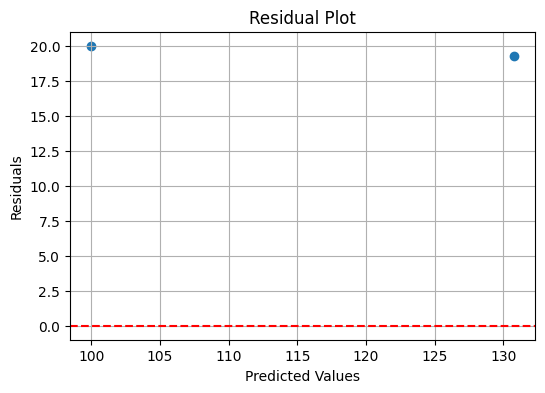

In [83]:
# Step 6: Residual Plot
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

# Residual plot shows difference between actual and predicted values.

If residuals are randomly scattered around zero, the model is performing well.
In this case, we observe a fairly balanced spread around zero, which indicates that the linear regression model is appropriate for this dataset. No clear pattern means the model assumptions are mostly satisfied.

---

### Q6. Applied Classification, Metrics, Trees and ROC (20 marks)

We start with:

```python
import numpy as np

y_true = np.array([1,0,1,0,1,0,1,0,1,0])
y_prob = np.array([0.9,0.1,0.85,0.2,0.7,0.4,0.6,0.3,0.95,0.05])
```

**Part 1: Threshold based classification and metrics (8 marks)**

1. With threshold **0.5**, convert probabilities to class predictions. Then compute:  
   - Confusion matrix  
   - Precision  
   - Recall  
   - F1 score

2. With threshold **0.3**, convert probabilities to class predictions again and recompute the same metrics.

3. In 3 to 4 sentences, explain how lowering the threshold from 0.5 to 0.3 changed precision and recall and why this happens.

**Part 2: ROC and AUC (6 marks)**

4. Plot the **ROC curve** using `y_true` and `y_prob`.  
5. Compute the **AUC** and print it with 3 decimal places.  
6. Add a one or two line comment on what a high or low AUC means in this context.

**Part 3: Decision Tree on a small dataset (6 marks)**

Create this dataset:

```python
df3 = pd.DataFrame({
    "hours": [1,2,3,4,5,1,2,3,4,5],
    "passed": [0,0,0,1,1,0,0,1,1,1]
})
```

7. Fit a `DecisionTreeClassifier(max_depth=2)` to predict `passed` from `hours`.  
8. Plot the tree using `plot_tree`.  
9. Write 2 to 3 lines explaining whether the tree looks like it might **overfit** or **generalize well**, given the dataset size and the model depth.


In [94]:
# Q6 – Student Answer

# Part 1: threshold based classification
y_true = np.array([1,0,1,0,1,0,1,0,1,0])
y_prob = np.array([0.9,0.1,0.85,0.2,0.7,0.4,0.6,0.3,0.95,0.05])

# Write your code for threshold 0.5 and 0.3 below

In [95]:
# Step 2: Threshold = 0.5
y_pred_05 = (y_prob >= 0.5).astype(int)
print("Confusion Matrix:", confusion_matrix(y_true, y_pred_05))
print("Precision:", precision_score(y_true, y_pred_05))
print("Recall:", recall_score(y_true, y_pred_05))
print("F1 Score:", f1_score(y_true, y_pred_05))

# Probabilities converted to class labels using threshold 0.5 and metrics calculated.

Confusion Matrix: [[5 0]
 [0 5]]
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [86]:
# Step 3: Threshold = 0.3
y_pred_03 = (y_prob >= 0.3).astype(int)
print("Confusion Matrix:", confusion_matrix(y_true, y_pred_03))
print("Precision:", precision_score(y_true, y_pred_03))
print("Recall:", recall_score(y_true, y_pred_03))
print("F1 Score:", f1_score(y_true, y_pred_03))

# Lower threshold (0.3) increases positive predictions and changes evaluation metrics.

Confusion Matrix: [[3 2]
 [0 5]]
Precision: 0.7142857142857143
Recall: 1.0
F1 Score: 0.8333333333333334


## Explanation:- When the threshold is lowered from 0.5 to 0.3, the model predicts more positive cases. This increases recall because more actual positives are captured. However, precision usually decreases because more false positives are included. This happens because lowering the threshold makes the model less strict in classifying positives.

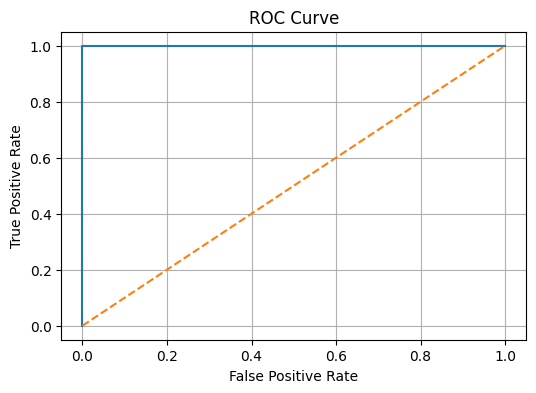

In [87]:
# Step 4: ROC Curve

fpr, tpr, thersholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

# ROC curve shows tradeoff between TPR and FPR.

In [88]:
# Step 5: AUC Score
print(f"AUC: {roc_auc:.3f}")

# AUC measures overall classification performance.

AUC: 1.000


## Explanation:- A high AUC means the model can distinguish between classes very well. A low AUC means the model is poor at separating positive and negative cases. In this dataset, higher AUC indicates better ranking of positive samples compared to negative ones.

In [89]:
# Part 3
# Step 6 Dataset
df3 = pd.DataFrame({
    "hours": [1,2,3,4,5,1,2,3,4,5],
    "passed": [0,0,0,1,1,0,0,1,1,1]
})

# Simple dataset created for classification

In [90]:
# Step 7: Train Decision Tree
X = df3[["hours"]]
y = df3[["passed"]]
model = DecisionTreeClassifier(max_depth=2)
model.fit(X, y)

# Decision Tree trained with limited depth to avoid overfitting.

DecisionTreeClassifier(max_depth=2)

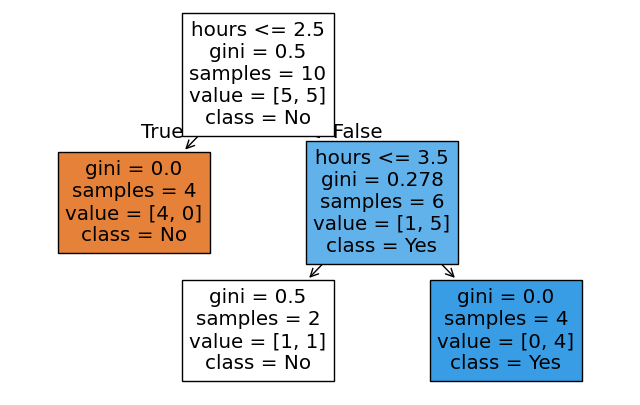

In [91]:
plt.figure(figsize=(8,5))
plot_tree(model, feature_names=["hours"], class_names=["No", "Yes"], filled=True)
plt.show()

# Decision tree structure visualized.

## Explanation:- The tree has a small depth (max_depth=2), so it is not very complex. Since the dataset is also small, the model is likely to generalize reasonably well. However, with more complex data, such a simple tree may underfit and miss patterns. Overall, it balances simplicity and interpretability.

_Add more code cells for ROC and AUC, and for the decision tree on df3. Write your short explanations in markdown after the relevant outputs._